# Solución para docentes de la sesión 07: desafío de clasificación para la puntuación de oportunidad top-price

> Advertencia: Este cuaderno es un laboratorio de enseñanza. El portátil básico de producción sigue siendo `05_classification_audi_a3_germany.ipynb`.

Esta práctica de laboratorio se ejecuta directamente desde archivos CSV procesados. No requiere credenciales en la nube, acceso BigQuery ni escrituras en el almacén.

Head Of Data 101 utiliza una idea central: **el canal es el producto**.

En este laboratorio, la clasificación predice una señal de calidad-precio del mercado externo. La salida del modelo es una capa de probabilidad. El artefacto empresarial es una cola de revisión, no una decisión de adquisición automática.

Esta versión compara dos definiciones de objetivos con el mismo conjunto de características observables:

- `top_price_only`: la clase positiva es `price_label == "top-price"`.
- `top_price_plus_good_price`: la clase positiva es `price_label` en `("top-price", "good-price")`.

Límite narrativo del curso:

- `price_label` es una etiqueta de mercado observada.
- `top_price` es el objetivo binario estricto derivado de `price_label`.
- `top_price = 1` cuando `price_label == "top-price"`; en caso contrario `top_price = 0`.
- `top_price_plus_good_price` es una variante de enseñanza que amplía la clase positiva para incluir `good-price`.
- Ni `price_label` ni `price_label_id` ni ninguna columna de destino se pueden utilizar como funciones de entrada del modelo.
- Usar el objetivo, o una fuente directa del objetivo, como característica de entrada es una fuga de objetivo.
- La regresión permanece separada y predice `expected_price_eur`.
- BI luego combina el precio real, la brecha expected-price y la probabilidad top-price.

`price_eur` se utiliza como característica observable del mercado en cada variante de modelo. Cada ruta del modelo ahora mantiene el mismo contrato de características de entrada para mantener el laboratorio más simple y enfocado.

**Nota conceptual:** La selección de umbral no es una calibración de probabilidad. En esta práctica de laboratorio elegimos una regla operativa para la capacidad de revisión. No probamos formalmente que una puntuación de 0,80 signifique una frecuencia empírica del 80%.


## Agenda de sesión en vivo de 3 horas

- 00:00-00:20 - Definiciones de objetivos, fugas y contrato de datos
- 00:20-00:40 - Distribución de etiquetas y líneas de base ingenuas
- 00:40-01:20 - Regresión logística para ambas variantes objetivo
- 01:20-01:55 - Comparación de modelos entre variantes de destino
- 01:55-02:30 - Política de umbral y equilibrio precisión/recuperación
- 02:30-02:50 - QQQ00000Colas de revisión listas para QQQ
- 02:50-03:00 - Discusión y entrega


## Ruta en vivo mínima viable

Si el tiempo de clase se vuelve escaso, complete el Desafío 0, el Desafío 1, el Desafío 3 y finalice con la cola BI dirigida por el instructor del Desafío 5.


## Cómo trabajar

Este no es un curso puro de codificación. Utilice la codificación asistida por IA cuando sea útil, pero asegúrese de poder explicar cada resultado.

Para cada desafío, lea el motivo comercial, inspeccione el resultado dirigido por el instructor y escriba una breve interpretación comercial en inglés.

El cuaderno es ejecutable de extremo a extremo. Los estudiantes aún pueden hacer una pausa en cada desafío para interpretar el resultado antes de continuar.


## Desafío 0: contrato de datos de clasificación y límite de fuga

**Tiempo sugerido:** 20 minutos

**Demostración dirigida por un instructor**

**Razón comercial:**  
Antes de modelar, un científico de datos debe saber exactamente qué contrato de conjunto de datos se está consumiendo y de dónde proviene cada objetivo.

**Objetivo:**  
Cargue el CSV procesado, valide las columnas requeridas, cree `listing_id` si es necesario, cree ambas variantes de destino a partir de `price_label` y prepare un marco de datos de modelado.

**Límite de característica:**
- `price_label` es la etiqueta del mercado observado que se utiliza para definir los objetivos.
- `top_price` y `top_price_plus_good_price` son objetivos.
- `price_label`, `price_label_id`, `top_price` y `top_price_plus_good_price` no pueden ser funciones.
- `price_eur` es observable en el mercado y es obligatorio en todas las variantes del modelo.
- `actual_price_eur`, cuando está presente como un nombre duplicado de BI, no se utiliza como una característica independiente.

**Pausa de discusión:**
- ¿Cómo cambia la acción de clase positiva cuando se incluye `good-price`?
- ¿Por qué `price_eur` es diferente de la fuga objetivo?
- ¿Por qué la definición del objetivo debería fallar estrepitosamente en lugar de ser adivinada?


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.3f}".format)
plt.style.use("default")


def find_repo_root(start):
    for path in [start] + list(start.parents):
        if (path / ".git").exists() or (path / "config" / "project_config.yaml").exists():
            return path
    return start


def load_project_config(config_path):
    config = {}
    if not config_path.exists():
        return config
    for raw_line in config_path.read_text(encoding="utf-8-sig").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or ":" not in line:
            continue
        key, value = line.split(":", 1)
        key = key.strip()
        value = value.strip()
        if value.startswith(("'", '"')) and value.endswith(("'", '"')):
            value = value[1:-1]
        elif value.lower() in ("true", "false"):
            value = value.lower() == "true"
        else:
            try:
                value = int(value)
            except ValueError:
                try:
                    value = float(value)
                except ValueError:
                    pass
        config[key] = value
    return config


def relative_path(path):
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def csv_missing_required_columns(path, required_columns):
    try:
        columns = pd.read_csv(path, nrows=0).columns
    except Exception as exc:
        return required_columns, str(exc)
    missing = [column for column in required_columns if column not in columns]
    return missing, None


def csv_contains_required_columns(path, required_columns):
    missing, error = csv_missing_required_columns(path, required_columns)
    return not missing and error is None


def newest_csv_in_folder(folder):
    if not folder.exists():
        return None
    csv_files = [path for path in folder.glob("*.csv") if path.is_file()]
    if not csv_files:
        return None
    return max(csv_files, key=lambda path: path.stat().st_mtime)


def newest_data_csv_with_required_columns(data_root, required_columns):
    if not data_root.exists():
        return None
    candidates = []
    for path in data_root.rglob("*.csv"):
        if path.is_file() and csv_contains_required_columns(path, required_columns):
            candidates.append(path)
    if not candidates:
        return None
    return max(candidates, key=lambda path: path.stat().st_mtime)


def select_processed_csv(required_columns, preferred_filename):
    preferred_paths = [
        ("Preferred full classroom sample CSV (local)", processed_folder / preferred_filename),
        ("Repo-visible fallback sample", sample_processed_folder / preferred_filename),
    ]
    rejected = []

    for source_label, candidate in preferred_paths:
        if candidate.exists():
            missing, error = csv_missing_required_columns(candidate, required_columns)
            if not missing and error is None:
                return candidate, source_label
            rejected.append((source_label, candidate, missing, error))

    candidate = newest_csv_in_folder(processed_folder)
    if candidate is not None:
        missing, error = csv_missing_required_columns(candidate, required_columns)
        if not missing and error is None:
            return candidate, "Latest local processed CSV"
        rejected.append(("Latest local processed CSV", candidate, missing, error))

    candidate = newest_data_csv_with_required_columns(PROJECT_ROOT / "data", required_columns)
    if candidate is not None:
        return candidate, "Last-resort scan for any CSV with required columns"

    details = []
    for source_label, path, missing, error in rejected:
        if error:
            details.append(f"{source_label}: {relative_path(path)} could not be read ({error})")
        else:
            details.append(f"{source_label}: {relative_path(path)} missing {missing}")
    raise FileNotFoundError(
        "No processed CSV with the required classification columns was found. "
        "Run Notebook 02 to create data/processed/*.csv, or use data/sample/processed/.\n"
        + "\n".join(details)
    )


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(numeric_columns, categorical_columns, scale_numeric=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_transformer = Pipeline(numeric_steps)
    transformers = [("numeric", numeric_transformer, numeric_columns)]

    if categorical_columns:
        categorical_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", make_one_hot_encoder()),
        ])
        transformers.append(("categorical", categorical_transformer, categorical_columns))

    return ColumnTransformer(transformers=transformers)


def build_model_pipeline(model_type, use_class_weight):
    if model_type == "Logistic Regression":
        class_weight = "balanced" if use_class_weight else None
        return Pipeline([
            ("preprocess", build_preprocessor(numeric_features, categorical_features, scale_numeric=True)),
            ("model", LogisticRegression(max_iter=2000, class_weight=class_weight)),
        ])

    if model_type == "Random Forest":
        class_weight = "balanced_subsample" if use_class_weight else None
        return Pipeline([
            ("preprocess", build_preprocessor(numeric_features, categorical_features, scale_numeric=False)),
            ("model", RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                random_state=RANDOM_SEED,
                n_jobs=-1,
                class_weight=class_weight,
            )),
        ])

    if model_type == "HistGradientBoosting":
        return Pipeline([
            ("preprocess", build_preprocessor(numeric_features, categorical_features, scale_numeric=False)),
            ("model", HistGradientBoostingClassifier(
                max_iter=150,
                learning_rate=0.08,
                random_state=RANDOM_SEED,
            )),
        ])

    raise ValueError(f"Unknown model_type: {model_type}")


def safe_roc_auc(y_true, y_score):
    if y_score is None or pd.Series(y_true).nunique() < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_score)
    except ValueError:
        return np.nan


def evaluate_classifier(target_variant, model_type, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    return {
        "target_variant": target_variant,
        "model_type": model_type,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": safe_roc_auc(y_test, y_score),
        "predictions": y_pred,
        "probabilities": y_score,
    }


def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    image = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1], labels=["negative", "positive"])
    ax.set_yticks([0, 1], labels=["negative", "positive"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            ax.text(col, row, int(cm[row, col]), ha="center", va="center", color="black")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def build_threshold_table(y_true, y_score, thresholds):
    rows = []
    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "selected_count": int(y_pred.sum()),
            "selected_rate": float(y_pred.mean()),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows)


def result_metrics_only(result):
    return {k: v for k, v in result.items() if k not in ["predictions", "probabilities"]}


REQUIRED_COLUMNS = ["price_label", "price_eur", "mileage_km", "age_years", "power_hp"]
SESSION_07_FULL_CSV = "autoscout24_listings_processed_audi_a3_germany_20251228_205210.csv"
OPTIONAL_COLUMNS = [
    "listing_id",
    "make",
    "model",
    "brand",
    "fuel_type",
    "listing_country",
    "price_eur",
    "actual_price_eur",
    "registration_year",
    "registration_month",
    "price_outlier_iqr",
    "mileage_outlier_iqr",
    "power_outlier_iqr",
    "logical_issue",
]
LEAKAGE_COLUMNS = ["price_label", "price_label_id", "top_price", "top_price_plus_good_price"]
TARGET_VARIANTS = [
    {
        "target_variant": "top_price_only",
        "target_column": "top_price",
        "positive_labels": ["top-price"],
        "business_definition": "Positive when price_label is top-price only.",
    },
    {
        "target_variant": "top_price_plus_good_price",
        "target_column": "top_price_plus_good_price",
        "positive_labels": ["top-price", "good-price"],
        "business_definition": "Positive when price_label is top-price or good-price.",
    },
]
MODEL_TYPES = ["Logistic Regression", "Random Forest", "HistGradientBoosting"]

PROJECT_ROOT = find_repo_root(Path.cwd())
PROJECT_CONFIG = load_project_config(PROJECT_ROOT / "config" / "project_config.yaml")
RANDOM_SEED = int(PROJECT_CONFIG.get("random_state", 42))
np.random.seed(RANDOM_SEED)

make_scope = str(PROJECT_CONFIG.get("make", "Audi")).strip()
model_scope = str(PROJECT_CONFIG.get("model", "A3")).strip()
country_scope = str(PROJECT_CONFIG.get("country", "Germany")).strip()
TAG = f"{make_scope}_{model_scope}_{country_scope}".lower().replace(" ", "_")

processed_folder = PROJECT_ROOT / str(PROJECT_CONFIG.get("processed_data_path", "data/processed"))
sample_processed_folder = PROJECT_ROOT / "data" / "sample" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

selected_csv_path, selected_source = select_processed_csv(REQUIRED_COLUMNS, SESSION_07_FULL_CSV)
df_raw = pd.read_csv(selected_csv_path)
row_count_before = len(df_raw)
missing_required = [column for column in REQUIRED_COLUMNS if column not in df_raw.columns]
if missing_required:
    raise ValueError("Missing required classification columns: " + ", ".join(missing_required))

missing_optional = [column for column in OPTIONAL_COLUMNS if column not in df_raw.columns]
df = df_raw.copy()
created_listing_id = "listing_id" not in df.columns
had_top_price = "top_price" in df.columns

for column in ["mileage_km", "age_years", "power_hp", "price_eur", "actual_price_eur"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

df["price_label"] = df["price_label"].astype("string").str.strip().str.lower()
top_price_from_label = df["price_label"].eq("top-price").astype(int)

if had_top_price:
    top_price_text = df["top_price"].astype("string").str.strip().str.lower()
    top_price_text_map = top_price_text.map({"true": 1, "false": 0, "yes": 1, "no": 0, "1": 1, "0": 0})
    existing_top_price = pd.to_numeric(df["top_price"], errors="coerce")
    existing_top_price = existing_top_price.where(existing_top_price.notna(), top_price_text_map)
    invalid_existing_mask = existing_top_price.notna() & ~existing_top_price.isin([0, 1])
    if invalid_existing_mask.any():
        raise ValueError(
            "Existing top_price contains values other than 0/1 for "
            f"{int(invalid_existing_mask.sum())} rows. Fix the target definition before modeling."
        )
    mismatch_mask = existing_top_price.notna() & existing_top_price.astype("Int64").ne(top_price_from_label)
    if mismatch_mask.any():
        raise ValueError(
            "Existing top_price does not match price_label == 'top-price' for "
            f"{int(mismatch_mask.sum())} rows. Fix the target definition before modeling."
        )
    top_price_status = "present and validated against price_label"
else:
    top_price_status = "created from price_label"

df["top_price"] = top_price_from_label
df["top_price_plus_good_price"] = df["price_label"].isin(["top-price", "good-price"]).astype(int)

valid_modeling_rows = (
    df["price_label"].notna()
    & df["price_eur"].gt(0)
    & df["mileage_km"].gt(0)
    & df["age_years"].ge(0)
    & df["power_hp"].gt(0)
)
rows_removed = int((~valid_modeling_rows).sum())
df = df.loc[valid_modeling_rows].reset_index(drop=True)
if created_listing_id:
    df.insert(0, "listing_id", np.arange(1, len(df) + 1))
    missing_optional = [column for column in missing_optional if column != "listing_id"]

if df.empty:
    raise ValueError("The selected CSV has no valid modeling rows after filtering.")
for variant in TARGET_VARIANTS:
    if df[variant["target_column"]].nunique() < 2:
        raise ValueError(f"The target {variant['target_column']} has only one class after filtering.")

numeric_features = ["price_eur", "mileage_km", "age_years", "power_hp"]
categorical_features = []
if "fuel_type" in df.columns and df["fuel_type"].nunique(dropna=True) > 1:
    categorical_features.append("fuel_type")
feature_columns = numeric_features + categorical_features
excluded_feature_columns = [column for column in LEAKAGE_COLUMNS + ["actual_price_eur"] if column in df.columns]

print("Selected CSV:", relative_path(selected_csv_path))
print("Source priority:", selected_source)
print("Configured scope:", make_scope, model_scope, country_scope)
print("Rows before filtering:", row_count_before)
print("Rows after filtering:", len(df))
print("Rows removed by required-value filter:", rows_removed)
print("Strict target definition: top_price = 1 when price_label == 'top-price', otherwise 0")
print("Broader teaching target: top_price_plus_good_price = 1 when price_label is 'top-price' or 'good-price'")
print("top_price status:", top_price_status)
print("Feature columns used by every model variant:", feature_columns)
print("Excluded from model features because of leakage or duplicate BI naming:", excluded_feature_columns)
if missing_optional:
    print("Optional columns not found in this CSV:", ", ".join(missing_optional))

print("\nFirst 5 rows:")
display(df.head())

print("Missing values summary:")
missing_summary = df.isna().sum().sort_values(ascending=False).to_frame("missing_values")
display(missing_summary[missing_summary["missing_values"] > 0])


Selected CSV: data\processed\autoscout24_listings_processed_audi_a3_germany_20251228_205210.csv
Source priority: Preferred full classroom sample CSV (local)
Configured scope: Audi A3 Germany
Rows before filtering: 3381
Rows after filtering: 3352
Rows removed by required-value filter: 29
Strict target definition: top_price = 1 when price_label == 'top-price', otherwise 0
Broader teaching target: top_price_plus_good_price = 1 when price_label is 'top-price' or 'good-price'
top_price status: created from price_label
Feature columns used by every model variant: ['price_eur', 'mileage_km', 'age_years', 'power_hp', 'fuel_type']
Excluded from model features because of leakage or duplicate BI naming: ['price_label', 'top_price', 'top_price_plus_good_price']
Optional columns not found in this CSV: actual_price_eur

First 5 rows:


,listing_id,make,model,brand,price_eur,price_label,mileage_km,power_hp,registration_date,registration_year,registration_month,fuel_type,listing_country,page,price_outlier_iqr,mileage_outlier_iqr,power_outlier_iqr,logical_issue,age_years,top_price,top_price_plus_good_price
0,1,audi,a3,audi,4999,good-price,"261,200.000",140.000,2008-08-01,"2,008.000",8.000,diesel,germany,1,False,False,False,False,17.000,0,1
1,2,audi,a3,audi,16980,good-price,"76,000.000",179.000,2014-12-01,"2,014.000",12.000,petrol,germany,1,False,False,False,False,11.000,0,1
2,3,audi,a3,audi,9750,top-price,"174,549.000",110.000,2015-04-01,"2,015.000",4.000,diesel,germany,1,False,False,False,False,10.000,1,1
3,4,audi,a3,audi,13950,top-price,"91,700.000",179.000,2013-12-01,"2,013.000",12.000,petrol,germany,1,False,False,False,False,12.000,1,1
4,5,audi,a3,audi,34900,unknown,"18,900.000",150.000,2024-12-01,"2,024.000",12.000,petrol,germany,1,False,False,False,False,1.000,0,0


Missing values summary:


,missing_values


## Desafío 1: distribución de etiquetas y líneas de base ingenuas

**Tiempo sugerido:** 25 minutos

**Demostración dirigida por un instructor con interpretación del estudiante**

**Razón comercial:**  
La clasificación comienza con la etiqueta. Un modelo no se puede interpretar si no se comprende la clase positiva. Un clasificador también debe superar una línea de base simple.

**Objetivo:**  
Inspeccione la participación de clase positiva para ambas variantes objetivo y evalúe una línea de base de clase mayoritaria para cada una.

**Formato de salida esperado:**
- Tabla de frecuencias `price_label`.
- Recuento objetivo y tabla de porcentajes para ambas variantes.
- Gráfico de barras de distribución de clases.
- Métricas de referencia de clase mayoritaria.

**Pausa de discusión:**
- ¿Qué tan común es la clase positiva en cada variante objetivo?
- ¿Por qué agregar `good-price` hace que el objetivo sea más equilibrado?
- ¿Por qué la precisión puede ser engañosa?


,price_label,row_count,row_share
0,fair-price,1110,0.331
1,top-price,841,0.251
2,good-price,804,0.240
3,somewhat-expensive,275,0.082
4,unknown,251,0.075
5,toolow-price,54,0.016
6,expensive,17,0.005


,target_variant,class_value,row_count,row_share,positive_labels
0,top_price_only,0,2511,0.749,top-price
1,top_price_only,1,841,0.251,top-price
2,top_price_plus_good_price,0,1707,0.509,"top-price, good-price"
3,top_price_plus_good_price,1,1645,0.491,"top-price, good-price"


,target_variant,majority_class,accuracy,precision,recall,f1
0,top_price_only,0,0.750,0.000,0.000,0.000
1,top_price_plus_good_price,0,0.510,0.000,0.000,0.000


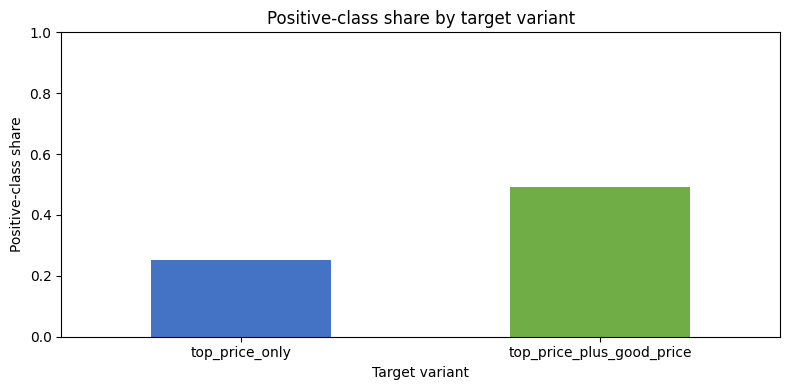

In [2]:
price_label_summary = (
    df["price_label"]
    .value_counts(dropna=False)
    .rename_axis("price_label")
    .reset_index(name="row_count")
)
price_label_summary["row_share"] = price_label_summary["row_count"] / len(df)
display(price_label_summary)

X = df[feature_columns].copy()
splits = {}
baseline_rows = []
target_summary_rows = []

for variant in TARGET_VARIANTS:
    target_variant = variant["target_variant"]
    target_column = variant["target_column"]
    y = df[target_column].astype(int)

    target_counts = y.value_counts().sort_index()
    for class_value, row_count in target_counts.items():
        target_summary_rows.append({
            "target_variant": target_variant,
            "class_value": int(class_value),
            "row_count": int(row_count),
            "row_share": row_count / len(y),
            "positive_labels": ", ".join(variant["positive_labels"]),
        })

    train_index, test_index = train_test_split(
        df.index,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=y,
    )
    y_train = y.loc[train_index]
    y_test = y.loc[test_index]
    X_train = X.loc[train_index]
    X_test = X.loc[test_index]

    splits[target_variant] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "train_index": train_index,
        "test_index": test_index,
    }

    majority_class = int(y_train.mode()[0])
    y_pred_baseline = np.repeat(majority_class, len(y_test))
    baseline_rows.append({
        "target_variant": target_variant,
        "majority_class": majority_class,
        "accuracy": accuracy_score(y_test, y_pred_baseline),
        "precision": precision_score(y_test, y_pred_baseline, zero_division=0),
        "recall": recall_score(y_test, y_pred_baseline, zero_division=0),
        "f1": f1_score(y_test, y_pred_baseline, zero_division=0),
    })

target_summary = pd.DataFrame(target_summary_rows)
baseline_metrics_df = pd.DataFrame(baseline_rows)

display(target_summary)
display(baseline_metrics_df)

fig, ax = plt.subplots(figsize=(8, 4))
positive_share = target_summary[target_summary["class_value"] == 1].set_index("target_variant")["row_share"]
positive_share.plot(kind="bar", ax=ax, color=["#4472C4", "#70AD47"])
ax.set_title("Positive-class share by target variant")
ax.set_xlabel("Target variant")
ax.set_ylabel("Positive-class share")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Etiqueta e interpretación de referencia

1. Participación de clase positiva para `top_price_only`:
2. Acción de clase positiva para `top_price_plus_good_price`:
3. ¿La línea de base mayoritaria detectó positivos?
4. ¿Qué métrica hace visible la falla inicial?
5. ¿Por qué es más fácil aprender el objetivo más amplio como una tarea de clasificación equilibrada?


## Desafío 2: Regresión logística como primer clasificador

**Tiempo sugerido:** 40 minutos

**Demostración dirigida por un instructor con interpretación del estudiante**

**Razón comercial:**  
Un científico de datos profesional comienza con un modelo transparente antes de pasar a modelos flexibles.

**Objetivo:**  
Entrene la regresión logística para ambas variantes de destino utilizando el mismo conjunto de funciones. Cada modelo incluye `price_eur`.

**Conjunto de funciones para todas las variantes:**
- `price_eur`
- `mileage_km`
- `age_years`
- `power_hp`
- `fuel_type` si está disponible

**No incluye:** `price_label`, `price_label_id`, `top_price`, `top_price_plus_good_price` o `actual_price_eur`.

**Formato de salida esperado:**
- Tabla de métricas que comparan ambas variantes de objetivos.
- Matrices de confusión para ambos modelos de Regresión Logística.
- Breve interpretación de precisión y recuperación.


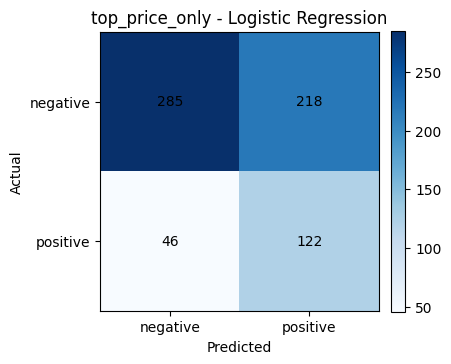

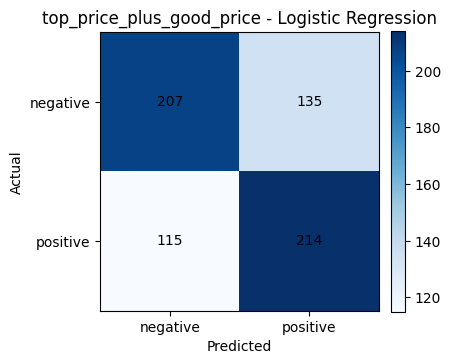

,target_variant,model_type,accuracy,precision,recall,f1,roc_auc,class_weight_used
0,top_price_only,Logistic Regression,0.607,0.359,0.726,0.480,0.691,True
1,top_price_plus_good_price,Logistic Regression,0.627,0.613,0.650,0.631,0.687,False


In [3]:
logreg_rows = []
logreg_results = {}
logreg_artifacts = {}

for variant in TARGET_VARIANTS:
    target_variant = variant["target_variant"]
    split = splits[target_variant]
    y_train = split["y_train"]
    minority_share = y_train.value_counts(normalize=True).min()
    use_class_weight = minority_share < 0.30

    pipeline = build_model_pipeline("Logistic Regression", use_class_weight=use_class_weight)
    result = evaluate_classifier(
        target_variant,
        "Logistic Regression",
        pipeline,
        split["X_train"],
        split["X_test"],
        y_train,
        split["y_test"],
    )
    result["class_weight_used"] = bool(use_class_weight)
    logreg_results[target_variant] = result
    logreg_artifacts[target_variant] = {"pipeline": pipeline, "X_all": X, "target_column": variant["target_column"]}
    logreg_rows.append(result_metrics_only(result))

    cm = confusion_matrix(split["y_test"], result["predictions"], labels=[0, 1])
    plot_confusion_matrix(cm, f"{target_variant} - Logistic Regression")

logreg_metrics_df = pd.DataFrame(logreg_rows)
display(logreg_metrics_df)


### Interpretación de la regresión logística

1. ¿Qué variante objetivo tiene mayor recuerdo?
2. ¿Qué variante de objetivo tiene mayor precisión?
3. ¿Es útil el modelo estricto `top_price_only` como filtro de primera revisión?
4. ¿Qué cambia cuando `good-price` se incluye en la clase positiva?


## Desafío 3: Comparación de modelos entre variantes de destino

**Tiempo sugerido:** 35 minutos

**Demostración dirigida por un instructor con interpretación del estudiante**

**Razón comercial:**  
Los modelos flexibles pueden capturar patrones no lineales, pero pueden ser más difíciles de explicar. Una comparación justa utiliza las mismas características de entrada y cambia solo la familia de modelos o la definición de destino.

**Objetivo:**  
Compare la regresión logística, el bosque aleatorio y el HistGradientBoosting para ambas variantes de destino. Cada variante utiliza `price_eur`.

**Formato de salida esperado:**
- Tabla de comparación entre variantes de destino y versiones de modelos.
- Mejor modelo por variante objetivo.
- Matrices de confusión para el modelo seleccionado en cada variante objetivo.
- Comparación guardada CSV en `reports/`.

**Pausa de discusión:**
- ¿El objetivo más amplio mejora la recuperación, F1 o ROC-AUC?
- ¿Qué modelo es mejor para una cola de revisión?
- ¿Qué métrica respalda esa decisión?
- ¿La ganancia vale la complejidad?


Saved model comparison to: reports\audi_a3_germany_classification_model_comparison.csv


,target_variant,model_type,accuracy,precision,recall,f1,roc_auc,class_weight_used,positive_share_train,rank_within_target
0,top_price_only,Random Forest,0.757,0.514,0.565,0.538,0.754,True,0.251,1
1,top_price_only,HistGradientBoosting,0.790,0.606,0.458,0.522,0.778,False,0.251,2
2,top_price_only,Logistic Regression,0.607,0.359,0.726,0.480,0.691,True,0.251,3
3,top_price_plus_good_price,HistGradientBoosting,0.724,0.722,0.711,0.717,0.775,False,0.491,1
4,top_price_plus_good_price,Logistic Regression,0.627,0.613,0.650,0.631,0.687,False,0.491,2
5,top_price_plus_good_price,Random Forest,0.657,0.683,0.562,0.617,0.733,False,0.491,3


Best model per target variant by F1, then ROC-AUC and recall:


,target_variant,model_type,accuracy,precision,recall,f1,roc_auc,class_weight_used,positive_share_train,rank_within_target
0,top_price_only,Random Forest,0.757,0.514,0.565,0.538,0.754,True,0.251,1
3,top_price_plus_good_price,HistGradientBoosting,0.724,0.722,0.711,0.717,0.775,False,0.491,1


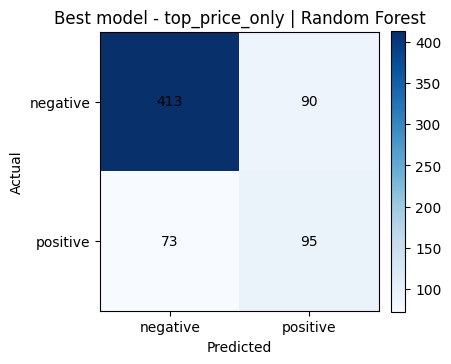

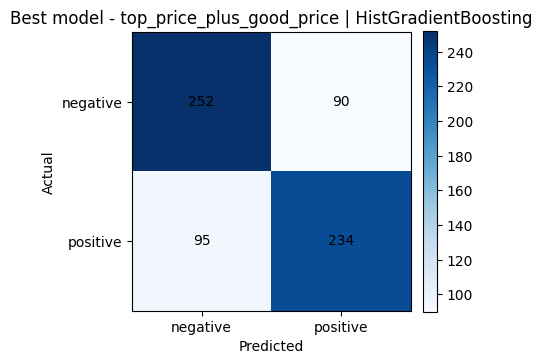

f1                                precision  \
target_variant       top_price_only top_price_plus_good_price top_price_only   
model_type                                                                     
HistGradientBoosting          0.522                     0.717          0.606   
Logistic Regression           0.480                     0.631          0.359   
Random Forest                 0.538                     0.617          0.514   

                                                       recall  \
target_variant       top_price_plus_good_price top_price_only   
model_type                                                      
HistGradientBoosting                     0.722          0.458   
Logistic Regression                      0.613          0.726   
Random Forest                            0.683          0.565   

                                                      roc_auc  \
target_variant       top_price_plus_good_price top_price_only   
model_type                                                      
HistGradientBoosting                     0.711          0.778   
Logistic Regression                      0.650          0.691   
Random Forest                            0.562          0.754   

                                                
target_variant       top_price_plus_good_price  
model_type                                      
HistGradientBoosting                     0.775  
Logistic Regression                      0.687  
Random Forest                            0.733

,model_type,precision_delta_broad_minus_strict,recall_delta_broad_minus_strict,f1_delta_broad_minus_strict,roc_auc_delta_broad_minus_strict
0,Logistic Regression,0.254,-0.076,0.151,-0.004
1,Random Forest,0.169,-0.003,0.078,-0.020
2,HistGradientBoosting,0.116,0.253,0.195,-0.003


Positive share moves from 25.1% to 49.1% when good-price is included.
Use the delta table to discuss whether each model improves because the target became more balanced.


In [4]:
model_results = {}
model_artifacts = {}
comparison_rows = []

for variant in TARGET_VARIANTS:
    target_variant = variant["target_variant"]
    target_column = variant["target_column"]
    split = splits[target_variant]
    y_train = split["y_train"]
    minority_share = y_train.value_counts(normalize=True).min()
    use_class_weight = minority_share < 0.30

    for model_type in MODEL_TYPES:
        pipeline = build_model_pipeline(model_type, use_class_weight=use_class_weight)
        result = evaluate_classifier(
            target_variant,
            model_type,
            pipeline,
            split["X_train"],
            split["X_test"],
            y_train,
            split["y_test"],
        )
        result["class_weight_used"] = bool(use_class_weight and model_type in ["Logistic Regression", "Random Forest"])
        result["positive_share_train"] = float(y_train.mean())
        result_key = f"{target_variant} | {model_type}"
        model_results[result_key] = result
        model_artifacts[result_key] = {"pipeline": pipeline, "X_all": X, "target_column": target_column}
        comparison_rows.append(result_metrics_only(result))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(
    ["target_variant", "f1", "roc_auc"],
    ascending=[True, False, False],
).reset_index(drop=True)
comparison_df["rank_within_target"] = comparison_df.groupby("target_variant")["f1"].rank(
    method="first",
    ascending=False,
).astype(int)

comparison_path = REPORTS_DIR / f"{TAG}_classification_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved model comparison to:", relative_path(comparison_path))
display(comparison_df)

best_models_df = comparison_df.sort_values(
    ["target_variant", "f1", "roc_auc", "recall"],
    ascending=[True, False, False, False],
).groupby("target_variant", as_index=False).head(1)
print("Best model per target variant by F1, then ROC-AUC and recall:")
display(best_models_df)

for _, row in best_models_df.iterrows():
    result_key = f"{row['target_variant']} | {row['model_type']}"
    split = splits[row["target_variant"]]
    cm = confusion_matrix(split["y_test"], model_results[result_key]["predictions"], labels=[0, 1])
    plot_confusion_matrix(cm, f"Best model - {result_key}")

metric_pivot = comparison_df.pivot_table(
    index="model_type",
    columns="target_variant",
    values=["precision", "recall", "f1", "roc_auc"],
)
display(metric_pivot)

strict_metrics = comparison_df[comparison_df["target_variant"] == "top_price_only"].set_index("model_type")
broad_metrics = comparison_df[comparison_df["target_variant"] == "top_price_plus_good_price"].set_index("model_type")
comparison_delta_df = pd.DataFrame({
    "model_type": MODEL_TYPES,
    "precision_delta_broad_minus_strict": [
        broad_metrics.loc[model, "precision"] - strict_metrics.loc[model, "precision"] for model in MODEL_TYPES
    ],
    "recall_delta_broad_minus_strict": [
        broad_metrics.loc[model, "recall"] - strict_metrics.loc[model, "recall"] for model in MODEL_TYPES
    ],
    "f1_delta_broad_minus_strict": [
        broad_metrics.loc[model, "f1"] - strict_metrics.loc[model, "f1"] for model in MODEL_TYPES
    ],
    "roc_auc_delta_broad_minus_strict": [
        broad_metrics.loc[model, "roc_auc"] - strict_metrics.loc[model, "roc_auc"] for model in MODEL_TYPES
    ],
})
display(comparison_delta_df)

strict_positive_share = comparison_df.loc[
    comparison_df["target_variant"] == "top_price_only", "positive_share_train"
].iloc[0]
broad_positive_share = comparison_df.loc[
    comparison_df["target_variant"] == "top_price_plus_good_price", "positive_share_train"
].iloc[0]
print(f"Positive share moves from {strict_positive_share:.1%} to {broad_positive_share:.1%} when good-price is included.")
print("Use the delta table to discuss whether each model improves because the target became more balanced.")


### Decisión de comparación de modelos

1. Modelo seleccionado para `top_price_only`:
2. Modelo seleccionado para `top_price_plus_good_price`:
3. Evidencia métrica:
4. Compensación entre una calidad objetivo estricta y un equilibrio objetivo más amplio:
5. Compensación entre desempeño y explicabilidad:


## Desafío 4: Política de umbral y capacidad de revisión

**Tiempo sugerido:** 35 minutos

**Demostración dirigida por un instructor y pausa de discusión**

**Razón comercial:**  
Un clasificador genera probabilidades. El umbral es una decisión operativa, no una verdad modelo.

**Objetivo:**  
Para obtener el mejor modelo en cada variante objetivo, analice cómo los diferentes umbrales de probabilidad cambian la precisión, la recuperación, la F1 y la cantidad de listados seleccionados.

**Formato de salida esperado:**
- Tabla de umbrales para 0,30, 0,40, 0,50, 0,60, 0,70.
- Gráfico de umbral versus precisión y recuperación.
- Umbral recomendado o política Top-N.

**Pausa de discusión:**
- Los falsos positivos consumen tiempo del analista.
- Los falsos negativos pierden oportunidades.
- 0,50 no es automáticamente correcto.
- Umbral es una política operativa para la capacidad de revisión.


Saved threshold analysis to: reports\audi_a3_germany_classification_threshold_analysis.csv


,target_variant,model_type,threshold,selected_count,selected_rate,precision,recall,f1
0,top_price_only,Random Forest,0.300,481,0.717,0.308,0.881,0.456
1,top_price_only,Random Forest,0.400,347,0.517,0.369,0.762,0.497
2,top_price_only,Random Forest,0.500,185,0.276,0.514,0.565,0.538
3,top_price_only,Random Forest,0.600,108,0.161,0.648,0.417,0.507
4,top_price_only,Random Forest,0.700,68,0.101,0.632,0.256,0.364
5,top_price_plus_good_price,HistGradientBoosting,0.300,443,0.660,0.625,0.842,0.718
6,top_price_plus_good_price,HistGradientBoosting,0.400,378,0.563,0.672,0.772,0.719
7,top_price_plus_good_price,HistGradientBoosting,0.500,324,0.483,0.722,0.711,0.717
8,top_price_plus_good_price,HistGradientBoosting,0.600,259,0.386,0.757,0.596,0.667
9,top_price_plus_good_price,HistGradientBoosting,0.700,188,0.280,0.787,0.450,0.573


Recommended thresholds by target variant: {'top_price_only': 0.5, 'top_price_plus_good_price': 0.4}


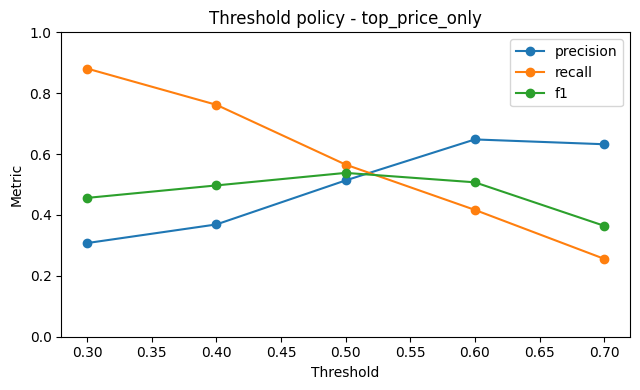

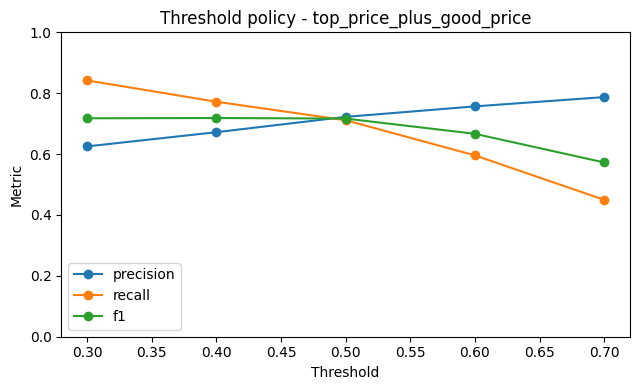

In [5]:
threshold_tables = []
recommended_thresholds = {}

for _, row in best_models_df.iterrows():
    target_variant = row["target_variant"]
    model_type = row["model_type"]
    result_key = f"{target_variant} | {model_type}"
    selected_result = model_results[result_key]
    split = splits[target_variant]

    table = build_threshold_table(
        split["y_test"],
        selected_result["probabilities"],
        thresholds=[0.30, 0.40, 0.50, 0.60, 0.70],
    )
    table.insert(0, "model_type", model_type)
    table.insert(0, "target_variant", target_variant)
    threshold_tables.append(table)

    best_threshold_row = table.sort_values(["f1", "recall"], ascending=[False, False]).iloc[0]
    recommended_thresholds[target_variant] = float(best_threshold_row["threshold"])

threshold_analysis_df = pd.concat(threshold_tables, ignore_index=True)
threshold_path = REPORTS_DIR / f"{TAG}_classification_threshold_analysis.csv"
threshold_analysis_df.to_csv(threshold_path, index=False)
print("Saved threshold analysis to:", relative_path(threshold_path))
display(threshold_analysis_df)
print("Recommended thresholds by target variant:", recommended_thresholds)

for target_variant, table in threshold_analysis_df.groupby("target_variant"):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(table["threshold"], table["precision"], marker="o", label="precision")
    ax.plot(table["threshold"], table["recall"], marker="o", label="recall")
    ax.plot(table["threshold"], table["f1"], marker="o", label="f1")
    ax.set_title(f"Threshold policy - {target_variant}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()


### Recomendación de política de umbral

1. Umbral recomendado o regla Top-N para `top_price_only`:
2. Umbral recomendado o regla Top-N para `top_price_plus_good_price`:
3. Volumen de revisión esperado:
4. Principal compensación comercial:
5. Por qué 0,50 no es automáticamente correcto:


## Desafío 5: colas de revisión de clasificación listas para BI

**Tiempo sugerido:** 20 minutos

**Demostración dirigida por un instructor con interpretación del estudiante**

**Razón comercial:**  
Un modelo de clasificación resulta útil sólo cuando crea un artefacto de revisión procesable.

**Objetivo:**  
Ajuste cada modelo seleccionado en todas las filas válidas, genere una puntuación de probabilidad y cree un `classification_review_queue` combinado para ambas variantes de destino.

**Formato de salida esperado:**
- `target_variant`
- `model_type`
- `probability_positive_label`
- `predicted_positive_label`
- `classification_review_queue`
- Salidas CSV guardadas en `reports/`

**Límite operativo importante:**  
En la evaluación histórica, está bien mantener `price_label` y las columnas de destino en la cola de revisión para su validación. En la puntuación futura real, `price_label` y las columnas de destino no se conocerían y no se debería confiar en ellas operativamente.

**Pausa de discusión:**
- ¿Qué listados merecen la revisión de los analistas primero?
- ¿Qué variante objetivo crea un volumen de reseñas más realista?
- ¿Qué predicciones podrían ser artefactos del modelo?
- ¿Cómo debería mostrar Power BI esta salida?


In [6]:
context_columns = [
    column for column in [
        "listing_id",
        "make",
        "model",
        "brand",
        "price_eur",
        "mileage_km",
        "age_years",
        "power_hp",
        "fuel_type",
        "listing_country",
        "price_label",
        "top_price",
        "top_price_plus_good_price",
    ]
    if column in df.columns
]

queue_frames = []
for _, row in best_models_df.iterrows():
    target_variant = row["target_variant"]
    model_type = row["model_type"]
    target_column = next(v["target_column"] for v in TARGET_VARIANTS if v["target_variant"] == target_variant)
    result_key = f"{target_variant} | {model_type}"
    final_artifact = model_artifacts[result_key]
    final_model = final_artifact["pipeline"]
    final_model.fit(X, df[target_column].astype(int))

    probability_positive_label = final_model.predict_proba(X)[:, 1]
    threshold = recommended_thresholds[target_variant]
    predicted_positive_label = (probability_positive_label >= threshold).astype(int)

    queue = df[context_columns].copy()
    queue.insert(0, "target_variant", target_variant)
    queue.insert(1, "model_type", model_type)
    queue["threshold_used"] = threshold
    queue["probability_positive_label"] = probability_positive_label
    queue["predicted_positive_label"] = predicted_positive_label
    queue["review_rank"] = queue["probability_positive_label"].rank(method="first", ascending=False).astype(int)
    queue_frames.append(queue)

classification_review_queue = pd.concat(queue_frames, ignore_index=True)
classification_review_queue = classification_review_queue.sort_values(
    ["target_variant", "probability_positive_label"],
    ascending=[True, False],
).reset_index(drop=True)

queue_path = REPORTS_DIR / f"{TAG}_classification_review_queue.csv"
classification_review_queue.to_csv(queue_path, index=False)
print("Saved classification review queue to:", relative_path(queue_path))

display(classification_review_queue.groupby(["target_variant", "model_type", "threshold_used"])["predicted_positive_label"].agg(
    selected_count="sum",
    total_rows="count",
    selected_rate="mean",
).reset_index())

display(classification_review_queue.head(20))


Saved classification review queue to: reports\audi_a3_germany_classification_review_queue.csv


,target_variant,model_type,threshold_used,selected_count,total_rows,selected_rate
0,top_price_only,Random Forest,0.500,982,3352,0.293
1,top_price_plus_good_price,HistGradientBoosting,0.400,1898,3352,0.566


,target_variant,model_type,listing_id,make,model,brand,price_eur,mileage_km,age_years,power_hp,fuel_type,listing_country,price_label,top_price,top_price_plus_good_price,threshold_used,probability_positive_label,predicted_positive_label,review_rank
0,top_price_only,Random Forest,2976,audi,a3,audi,36880,"5,000.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.918,1,1
1,top_price_only,Random Forest,3225,audi,a3,audi,34250,"5,934.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.918,1,2
2,top_price_only,Random Forest,3081,audi,a3,audi,36880,"4,452.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.917,1,3
3,top_price_only,Random Forest,3186,audi,a3,audi,35450,"5,837.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.917,1,4
4,top_price_only,Random Forest,312,audi,a3,audi,36990,"4,564.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.915,1,5
5,top_price_only,Random Forest,2256,audi,a3,audi,36990,"5,000.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.915,1,6
6,top_price_only,Random Forest,3299,audi,a3,audi,36880,"4,145.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.914,1,7
7,top_price_only,Random Forest,2886,audi,a3,audi,36990,"5,691.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.911,1,8
8,top_price_only,Random Forest,2087,audi,a3,audi,36990,"6,000.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.910,1,9
9,top_price_only,Random Forest,2326,audi,a3,audi,36480,"7,873.000",0.000,150.000,diesel,germany,top-price,1,1,0.500,0.909,1,10


### BI conclusión del traspaso

1. Tres listados para revisión de analistas:
2. Riesgo de un modelo:
3. Un insumo empresarial que falta antes de tomar una decisión real:
4. ¿Debería BI exponer la puntuación estricta `top_price_only`, la puntuación más amplia `top_price_plus_good_price` o ambas?
5. ¿Qué debería mostrar Power BI junto a la puntuación para que los analistas no confundan la definición del objetivo?


## Extensión opcional: calibración de probabilidad

**Extensión opcional**

La calibración pregunta si las probabilidades predichas coinciden con las frecuencias observadas. Por ejemplo, entre los listados con una puntuación cercana a 0,80, ¿aproximadamente el 80% pertenece realmente a la clase positiva?

Esto es diferente de la selección de umbral. La selección de umbral elige una regla operativa para la capacidad de revisión. La calibración evalúa si la escala de probabilidad en sí es confiable.

No agregue calibración a la ruta del núcleo. Si se usa, discútalo conceptualmente o demuéstralo después de clase.


## Discusión final: ¿qué aprendimos sobre la clasificación como capa de priorización?

Utilice estas indicaciones para la discusión final en clase:

- ¿Por qué inspeccionamos el objetivo antes del entrenamiento?
- ¿Por qué construimos una base ingenua?
- ¿Por qué es peligrosa la precisión en una clasificación desequilibrada?
- ¿Por qué se permite `price_label` como origen del destino pero no como característica?
- ¿Por qué se requiere `price_eur` en cada variante de modelo aquí?
- ¿Qué es la fuga?
- ¿Cómo se relacionan la precisión y la recuperación con los costos comerciales?
- ¿Por qué agregar `good-price` crea un modelo objetivo más equilibrado?
- ¿Por qué la selección del umbral es una decisión política?
- ¿Cómo se convierte una puntuación de probabilidad en una capa de priorización lista para BI?

Mensaje final:

**Un clasificador útil no termina en una métrica. Termina en una capa de probabilidad que ayuda a las personas a priorizar la revisión, comprender las compensaciones y tomar mejores decisiones.**
